Week 3 — Data Preprocessing

*   Handle missing values (decide whether to drop, impute, or flag).
*   Convert categorical fields to numeric (encoding).
*   Normalize numerical features if needed.
*   Create train/test split: use the most recent month of available data as the test set, and the X months immediately preceding it as the training set. X is not fixed — treat the training window length as a tunable choice and experiment to determine the optimal value of X.
*   **Deliverable**: 02_preprocessing.ipynb + cleaned CSV.

In [22]:
from google.colab import drive
drive.mount('/content/drive')

import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

files = glob.glob("/content/drive/MyDrive/csv/CRMLSSold*.csv")
print(f"Found {len(files)} files")

df = pd.concat([pd.read_csv(f, low_memory=False) for f in files], ignore_index=True)
df = df.loc[:, ~df.columns.duplicated()]  # just in case a file repeats a column name

print(f"Loaded {len(df):,} rows, {df.shape[1]} columns")

df = df[
    (df["PropertyType"] == "Residential")
    & (df["PropertySubType"] == "SingleFamilyResidence")
].copy()

df["CloseDate"] = pd.to_datetime(df["CloseDate"], errors="coerce")
print(f"Rows after filtering: {len(df):,}")
print("Date range:", df["CloseDate"].min(), "to", df["CloseDate"].max())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 33 files
Loaded 736,473 rows, 84 columns
Rows after filtering: 371,215
Date range: 2024-01-01 00:00:00 to 2026-09-30 00:00:00


In [23]:
invalid_counts = {}

if "ClosePrice" in df.columns:
    bad = (df["ClosePrice"] <= 10_000) | (df["ClosePrice"] > 20_000_000)
    invalid_counts["ClosePrice"] = bad.sum()
    df.loc[bad, "ClosePrice"] = np.nan

if "LivingArea" in df.columns:
    bad = (df["LivingArea"] <= 100) | (df["LivingArea"] > 15_000)
    invalid_counts["LivingArea"] = bad.sum()
    df.loc[bad, "LivingArea"] = np.nan

if "BedroomsTotal" in df.columns:
    bad = (df["BedroomsTotal"] <= 0) | (df["BedroomsTotal"] > 12)
    invalid_counts["BedroomsTotal"] = bad.sum()
    df.loc[bad, "BedroomsTotal"] = np.nan

if "BathroomsTotalInteger" in df.columns:
    bad = (df["BathroomsTotalInteger"] <= 0) | (df["BathroomsTotalInteger"] > 12)
    invalid_counts["BathroomsTotalInteger"] = bad.sum()
    df.loc[bad, "BathroomsTotalInteger"] = np.nan

if "LotSizeSquareFeet" in df.columns:
    bad = (df["LotSizeSquareFeet"] <= 100) | (df["LotSizeSquareFeet"] > 1_000_000)
    invalid_counts["LotSizeSquareFeet"] = bad.sum()
    df.loc[bad, "LotSizeSquareFeet"] = np.nan

if "YearBuilt" in df.columns:
    bad = (df["YearBuilt"] < 1800) | (df["YearBuilt"] > 2026)
    invalid_counts["YearBuilt"] = bad.sum()
    df.loc[bad, "YearBuilt"] = np.nan

pd.Series(invalid_counts, name="rows flagged as missing").to_frame()


,rows flagged as missing
ClosePrice,265
LivingArea,213
BedroomsTotal,235
BathroomsTotalInteger,242
LotSizeSquareFeet,1595
YearBuilt,3


I flagged implausible values as missing and converted anything outside the range to NaN, so corrupted values get treated as missing rather than distorting later calculations.

**Findings:** Only 265 ClosePrice, 213 LivingArea, 235 BedroomsTotal, 242 BathroomsTotalInteger, 1595 LotSizeSquareFeet, and 3 Yearbuilt rows were flagged.

In [24]:
before = len(df)
df = df[df["ClosePrice"].notna()].copy()
print(f"Dropped {before - len(df):,} rows with missing/invalid ClosePrice ({(before-len(df))/before:.1%})")
print(f"Remaining rows: {len(df):,}")

impute_cols = [c for c in ["LivingArea", "BedroomsTotal", "BathroomsTotalInteger", "LotSizeSquareFeet", "YearBuilt"] if c in df.columns]
impute_medians = {}

for col in impute_cols:
    missing_mask = df[col].isna()
    df[f"{col}_was_missing"] = missing_mask.astype(int)
    median_val = df[col].median()
    impute_medians[col] = median_val
    df[col] = df[col].fillna(median_val)
    print(f"{col}: imputed {missing_mask.sum():,} rows ({missing_mask.mean():.1%}) with median={median_val:.1f}")

for col in ["City", "PostalCode"]:
    if col in df.columns:
        n_missing = df[col].isna().sum()
        df[col] = df[col].fillna("Unknown")
        print(f"{col}: filled {n_missing:,} missing with 'Unknown'")

print(f"\nFinal shape after missing-value handling: {df.shape}")
print("\nRemaining missingness check:")
print(df[impute_cols + ["City", "PostalCode"]].isna().sum())


Dropped 267 rows with missing/invalid ClosePrice (0.1%)
Remaining rows: 370,948
LivingArea: imputed 352 rows (0.1%) with median=1809.0
BedroomsTotal: imputed 229 rows (0.1%) with median=3.0
BathroomsTotalInteger: imputed 257 rows (0.1%) with median=2.0
LotSizeSquareFeet: imputed 7,974 rows (2.1%) with median=7246.0
YearBuilt: imputed 263 rows (0.1%) with median=1976.0
City: filled 253 missing with 'Unknown'
PostalCode: filled 3 missing with 'Unknown'

Final shape after missing-value handling: (370948, 89)

Remaining missingness check:
LivingArea               0
BedroomsTotal            0
BathroomsTotalInteger    0
LotSizeSquareFeet        0
YearBuilt                0
City                     0
PostalCode               0
dtype: int64


I dropped rows with missing/invalid ClosePrice values, imputed the 5 predictor columns with the median, and filled any City/PostalCode columns with "unknown".

**Findings:** Only 267 rows were dropped, leaving 370,948 rows. All the imputations affected 0.1-2.1% of rows. After the remaining missingness check, the data is cleaned.

In [25]:
def frequency_encode(train_series: pd.Series, apply_series: pd.Series) -> pd.Series:
    freq = train_series.value_counts(normalize=True)
    return apply_series.map(freq).fillna(0.0)

for col in ["City", "PostalCode"]:
    if col in df.columns:
        preview = frequency_encode(df[col], df[col])
        print(f"{col}: {df[col].nunique():,} unique values, frequency range "
              f"[{preview.min():.5f}, {preview.max():.5f}]")


City: 1,138 unique values, frequency range [0.00000, 0.03981]
PostalCode: 3,561 unique values, frequency range [0.00000, 0.00674]


In [26]:
numeric_features = [c for c in ["LivingArea", "BedroomsTotal", "BathroomsTotalInteger", "LotSizeSquareFeet", "YearBuilt"] if c in df.columns]
print("Columns to normalize:", numeric_features)


Columns to normalize: ['LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'LotSizeSquareFeet', 'YearBuilt']


In [27]:
def build_feature_frame(frame: pd.DataFrame, city_freq: dict, postalcode_freq: dict, medians: dict, scaler: StandardScaler, fit: bool):
    f = frame.copy()
    for col, med in medians.items():
        f[col] = f[col].fillna(med)
    if "City" in f.columns:
        f["City_freq"] = f["City"].map(city_freq).fillna(0.0)
    if "PostalCode" in f.columns:
        f["PostalCode_freq"] = f["PostalCode"].map(postalcode_freq).fillna(0.0)

    feature_cols = [c for c in numeric_features if c in f.columns] + \
                   [c for c in ["City_freq", "PostalCode_freq"] if c in f.columns]
    X = f[feature_cols].values
    if fit:
        X = scaler.fit_transform(X)
    else:
        X = scaler.transform(X)
    return X, feature_cols

In [28]:
df["CloseDate"] = pd.to_datetime(df["CloseDate"], errors="coerce")
test_month = df["CloseDate"].dt.to_period("M").max()
test_mask = df["CloseDate"].dt.to_period("M") == test_month
test_df_full = df[test_mask].copy()

months_available_before_test = df.loc[~test_mask, "CloseDate"].dt.to_period("M").nunique()
print(f"Test month: {test_month}  ({len(test_df_full):,} rows)")
print(f"Months of history available before the test month: {months_available_before_test}")

CANDIDATE_X_MONTHS = [1, 2, 3, 6, 9, 12, 18, 24]
candidates = [x for x in CANDIDATE_X_MONTHS if x <= months_available_before_test]
if not candidates:
    candidates = [months_available_before_test] if months_available_before_test > 0 else []
print(f"Candidate X values to sweep: {candidates}")

results = []
for X_months in candidates:
    window_start = (test_month - X_months).to_timestamp()
    window_end = test_month.to_timestamp()
    train_mask = (df["CloseDate"] >= window_start) & (df["CloseDate"] < window_end)
    train_df = df[train_mask].copy()

    if len(train_df) < 20:
        continue

    medians = {c: train_df[c].median() for c in numeric_features}
    city_freq = train_df["City"].value_counts(normalize=True).to_dict() if "City" in train_df.columns else {}
    zip_freq = train_df["PostalCode"].value_counts(normalize=True).to_dict() if "PostalCode" in train_df.columns else {}
    scaler = StandardScaler()

    X_train, feat_cols = build_feature_frame(train_df, city_freq, zip_freq, medians, scaler, fit=True)
    y_train = train_df["ClosePrice"].values

    X_test, _ = build_feature_frame(test_df_full, city_freq, zip_freq, medians, scaler, fit=False)
    y_test = test_df_full["ClosePrice"].values

    model = LinearRegression()
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    results.append({"X_months": X_months, "n_train": len(train_df), "MAE": mae, "RMSE": rmse})

results_df = pd.DataFrame(results)
results_df


Test month: 2026-09  (11,178 rows)
Months of history available before the test month: 32
Candidate X values to sweep: [1, 2, 3, 6, 9, 12, 18, 24]


,X_months,n_train,MAE,RMSE
0,1,11440,519702.198791,939321.441234
1,2,24299,519193.437152,938022.067073
2,3,37794,517757.217605,937244.464691
3,6,74282,519217.819505,937984.850798
4,9,101170,516713.568620,936903.378260
5,12,134368,515314.037445,936949.618918
6,18,203848,515442.117772,937376.829614
7,24,265372,515188.748092,937892.686516


September 2026 was locked in as the test set. From there, there is 32 months of data before that. I broke down the candidate X values into (1,2,3,6,9,12,18,24). For each candidate X, it takes that many months immediately before September as a training set, then re-does the encoding, imputation, and scaling from scratch using only that training window.

**Findings:** Across the different candidates, MAE barely changes and stays in a tight band from about $515,000 to $520,000. The best result came from the largest window tested, but the gap between the best and worst candidates is under 1%. RMSE sits almost double MAE the whole way through which indicates a handful of large prediction errors are inflating that metric.

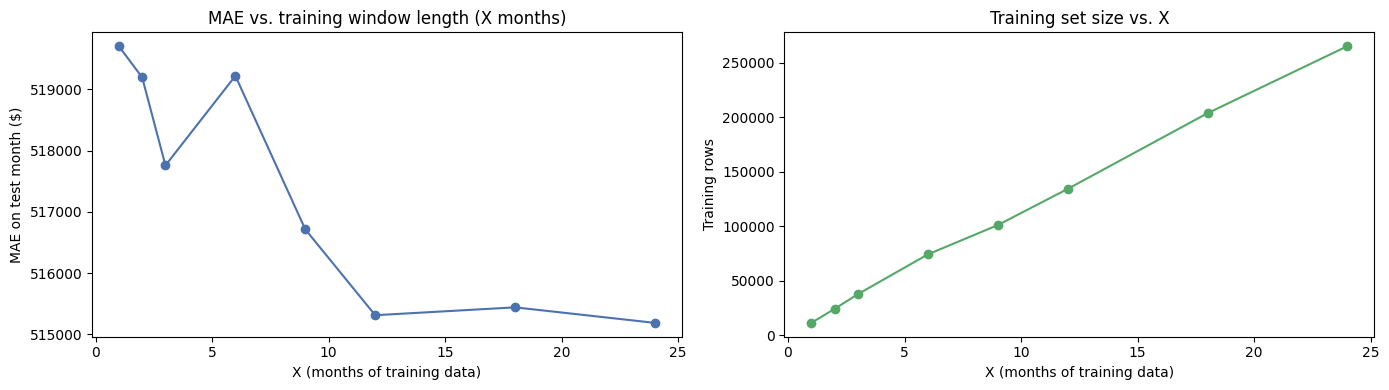

Use this plot to choose X: look for where MAE levels off or bottoms out.
More data (higher X) isn't always better for a time-series-like target — older months
may reflect a different market regime (e.g. different rates/prices) than the test month.


In [29]:
if len(results_df) > 1:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(results_df["X_months"], results_df["MAE"], marker="o", color="#4C72B0")
    axes[0].set_title("MAE vs. training window length (X months)")
    axes[0].set_xlabel("X (months of training data)")
    axes[0].set_ylabel("MAE on test month ($)")

    axes[1].plot(results_df["X_months"], results_df["n_train"], marker="o", color="#55A868")
    axes[1].set_title("Training set size vs. X")
    axes[1].set_xlabel("X (months of training data)")
    axes[1].set_ylabel("Training rows")

    plt.tight_layout()
    plt.show()

    print("Use this plot to choose X: look for where MAE levels off or bottoms out.")
    print("More data (higher X) isn't always better for a time-series-like target — older months")
    print("may reflect a different market regime (e.g. different rates/prices) than the test month.")
else:
    print("Not enough distinct candidate X values to plot a curve — need more months of history.")


Drawing the MAE and training-set-size against X side by side, we can see that the MAE line is nearly flat with a slight downward slope. The training-size line climbs steeply and linearly. The plots confirm that there's no sharp point where more data suddenly stops helping - it's gradual, weak trend the whole way.

In [30]:
if len(results_df):
    CHOSEN_X = int(results_df.loc[results_df["MAE"].idxmin(), "X_months"])  # <-- override this after reviewing the plot
    print(f"CHOSEN_X = {CHOSEN_X} (lowest-MAE candidate; review the plot above before trusting this)")
else:
    CHOSEN_X = None
    print("No candidates were evaluated — check that df has more than one month of data.")


CHOSEN_X = 24 (lowest-MAE candidate; review the plot above before trusting this)


The largest window tested happened to also have the lowest error, but this isn't a strongly confident choice because of the small enough margin.

In [31]:
if CHOSEN_X is not None:
    window_start = (test_month - CHOSEN_X).to_timestamp()
    window_end = test_month.to_timestamp()
    train_mask = (df["CloseDate"] >= window_start) & (df["CloseDate"] < window_end)

    train_final = df[train_mask].copy()
    test_final = test_df_full.copy()

    final_medians = {c: train_final[c].median() for c in numeric_features}
    final_city_freq = train_final["City"].value_counts(normalize=True).to_dict() if "City" in train_final.columns else {}
    final_zip_freq = train_final["PostalCode"].value_counts(normalize=True).to_dict() if "PostalCode" in train_final.columns else {}
    final_scaler = StandardScaler()

    X_train_final, feat_cols = build_feature_frame(train_final, final_city_freq, final_zip_freq, final_medians, final_scaler, fit=True)
    X_test_final, _ = build_feature_frame(test_final, final_city_freq, final_zip_freq, final_medians, final_scaler, fit=False)

    train_out = pd.DataFrame(X_train_final, columns=feat_cols, index=train_final.index)
    train_out["ClosePrice"] = train_final["ClosePrice"].values
    train_out["CloseDate"] = train_final["CloseDate"].values
    train_out["split"] = "train"

    test_out = pd.DataFrame(X_test_final, columns=feat_cols, index=test_final.index)
    test_out["ClosePrice"] = test_final["ClosePrice"].values
    test_out["CloseDate"] = test_final["CloseDate"].values
    test_out["split"] = "test"

    cleaned = pd.concat([train_out, test_out], ignore_index=True)
    print(f"Final train rows: {len(train_out):,} | test rows: {len(test_out):,}")
    cleaned.head()
else:
    cleaned = pd.DataFrame()
    print("Skipping final split — no valid CHOSEN_X.")


Final train rows: 265,372 | test rows: 11,178


Using the chosen X = 24 candidate, we build the final split into train_out and test_out DataFrames. The final split became 265,372 training rows and 11,178 test rows.

In [32]:
OUTPUT_DIR = "./output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

if len(cleaned):
    cleaned_path = os.path.join(OUTPUT_DIR, "cleaned_data.csv")
    cleaned.to_csv(cleaned_path, index=False)
    print(f"Saved: {cleaned_path}  ({len(cleaned):,} rows, {cleaned.shape[1]} columns)")

    train_out.to_csv(os.path.join(OUTPUT_DIR, "train.csv"), index=False)
    test_out.to_csv(os.path.join(OUTPUT_DIR, "test.csv"), index=False)
    print(f"Also saved: train.csv ({len(train_out):,} rows), test.csv ({len(test_out):,} rows)")
else:
    print("Nothing to save — CHOSEN_X was not set.")


Saved: ./output/cleaned_data.csv  (276,550 rows, 10 columns)
Also saved: train.csv (265,372 rows), test.csv (11,178 rows)
